# Notebook 04: Deriving KldB Future Profiles via ESCO

This notebook links the KldB -> ISCO -> ESCO mapping from 02 (`kldb_esco_mapping`) with the ESCO Occupation-Skill-Baseline from 03 (`occupation_skills_baseline`) and derives basic future profiles for KldB occupations (5-digit codes) from this. 
Additionally, the KldB alphabetical occupation names CSV is loaded and added as a new column to the baseline profiles.
Result:
- Long table `kldb_skill_soll_long` (each row: KldB code × ESCO occupation × skill)
- Aggregated version `kldb_skill_soll_agg` (one skill list per KldB code)
- Additional intermediate table `kldb_job_titles_long` as a long table (per row: KLDB code + job title)

(Sources as in the previous notebooks + Alphabetical directory of job titles (Federal Employment Agency, November 15, 2025, https://statistik.arbeitsagentur.de/DE/Navigation/Grundlagen/Klassifikationen/Klassifikation-der-Berufe/KldB2010-Fassung2020/Systematik-Verzeichnisse/Systematik-Verzeichnisse-Nav.html))

In [1]:
from pathlib import Path
import pandas as pd

# Project Root
PROJECT_ROOT   = Path.cwd().resolve().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM   = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Alphabetical List of Job Titles
job_titles_path = DATA_RAW / "kldb" / "Alphabetisches-Verzeichnis-Berufsbenennungen.csv"

print("Project root: ", PROJECT_ROOT)
print("Raw path:", DATA_RAW)
print("Interim path:", DATA_INTERIM)
print("Processed path:", DATA_PROCESSED)
print("Job titles path:", job_titles_path)

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

Project root:  C:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung
Raw path: C:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\raw
Interim path: C:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\interim
Processed path: C:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed
Job titles path: C:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\raw\kldb\Alphabetisches-Verzeichnis-Berufsbenennungen.csv


## 1. Load data

`kldb_esco_mapping.parquet` from Notebook 02 (KldB 5-digit -> ISCO 4-digit -> ESCO occupation/`conceptUri`) & `occupation_skills_baseline.parquet` from 03  (ESCO occupation -> Skills including `relation_type`, `reuse_level`, `skill_type`).

In [2]:
# Paths Files
kldb_mapping_path = DATA_INTERIM / "kldb_esco_mapping.parquet"
baseline_path     = DATA_INTERIM / "occupation_skills_baseline.parquet"

print("Mapping path: ", kldb_mapping_path)
print("Baseline path:", baseline_path)

# load
kldb_esco_mapping = pd.read_parquet(kldb_mapping_path)
occupation_skills_baseline = pd.read_parquet(baseline_path)

print("kldb_esco_mapping:", kldb_esco_mapping.shape)
print("occupation_skills_baseline:", occupation_skills_baseline.shape)

display(kldb_esco_mapping.head(3))
display(occupation_skills_baseline.head(3))

Mapping path:  C:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\interim\kldb_esco_mapping.parquet
Baseline path: C:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\interim\occupation_skills_baseline.parquet
kldb_esco_mapping: (18391, 12)
occupation_skills_baseline: (129004, 13)


,kldb_5_code,kldb_title_de,kldb_title_en,isco08_4,isco_title_de,isco_title_en,unambiguous_flag,focus_and_alt_count,occupation_uri,esco_title_en,esco_alt_labels_en,esco_description_en
0,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,fruit and vegetable picker,fruit picker\nfruit and vegetable harvester\nf...,Fruit and vegetable pickers select and harvest...
1,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/e5e3ea36...,vineyard worker,grape harvester\ngrape picker\nworker in a vin...,Vineyard workers carry out manual activities r...
2,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9213,Hilfsarbeiter in Ackerbau und Tierhaltung (ohn...,Mixed crop and livestock farm labourers,0,2,http://data.europa.eu/esco/occupation/c9191f7f...,crop production worker,farm worker\nfarm hand\ngrowing worker\ncrop w...,Crop production workers carry out practical ac...


,occupation_uri,occupation_code,isco_group,occupation_title_en,occupation_alt_labels_en,occupation_description_en,skill_uri,skill_title_en,skill_alt_labels_en,skill_description_en,reuse_level,skill_type,relation_type
0,http://data.europa.eu/esco/occupation/00030d09...,2654.1.7,2654,technical director,['technical and operations director\nhead of t...,Technical directors realise the artistic visio...,http://data.europa.eu/esco/skill/fed5b267-73fa...,theatre techniques,['theatre technique\ntheatre approaches\ntheat...,The techniques that facilitate a successful pr...,sector-specific,knowledge,essential
1,http://data.europa.eu/esco/occupation/00030d09...,2654.1.7,2654,technical director,['technical and operations director\nhead of t...,Technical directors realise the artistic visio...,http://data.europa.eu/esco/skill/05bc7677-5a64...,organise rehearsals,['organise rehearsal\norganize rehearsals\npla...,"Manage, schedule and run rehearsals for the pe...",sector-specific,skill/competence,essential
2,http://data.europa.eu/esco/occupation/00030d09...,2654.1.7,2654,technical director,['technical and operations director\nhead of t...,Technical directors realise the artistic visio...,http://data.europa.eu/esco/skill/271a36a0-bc7a...,write risk assessment on performing arts produ...,['write assessment of risks about performing a...,"Assess risks, propose improvements and describ...",sector-specific,skill/competence,essential


### 1.1 Load and process the alphabetical list of job titles

The list contains specific job titles for each 5-digit KldB code. Process the rows, normalize the KldB codes, and aggregate the job titles by KldB code:

In [3]:
# Load
job_titles_raw = pd.read_csv(job_titles_path, sep=";", encoding="latin1", engine="python") # Delimiter + latin1 due to umlauts

print("job_titles_raw shape:", job_titles_raw.shape)
display(job_titles_raw.head(10))
display(job_titles_raw.tail(10))

# Standardize columns
job_titles = job_titles_raw.rename(columns={"Berufsbenennungen": "job_title_de", "KldB 2010 (5-Steller)": "kldb_5_code"}).copy()

# Cleaning: Remove NaNs, footer lines, and codes that are not 5 digits long
job_titles["job_title_de"] = job_titles["job_title_de"].astype(str).str.strip()
job_titles["kldb_5_code"] = job_titles["kldb_5_code"].astype(str).str.strip()

# Exclude: empty/NaN titles or codes
job_titles = job_titles[
    job_titles["job_title_de"].notna() &
    job_titles["kldb_5_code"].notna() &
    (job_titles["job_title_de"] != "nan") &
    (job_titles["kldb_5_code"] != "nan")
].copy()

# Codes consisting only of digits, exactly 5 digits long
job_titles["kldb_5_code"] = job_titles["kldb_5_code"].str.replace(r"\.0$", "", regex=True)
job_titles["kldb_5_code"] = job_titles["kldb_5_code"].str.extract(r"(\d{5})", expand=False)
job_titles = job_titles.dropna(subset=["kldb_5_code"]).copy()
job_titles["kldb_5_code"] = job_titles["kldb_5_code"].astype(str).str.zfill(5) # rounded to 5 decimal places

# Clean up the title
job_titles["job_title_de"] = (
    job_titles["job_title_de"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Deduplication
before = len(job_titles)
job_titles = job_titles.drop_duplicates(subset=["kldb_5_code", "job_title_de"]).reset_index(drop=True)
after = len(job_titles)
print(f"Dedup job titles: {before} -> {after}")

print("job_titles cleaned shape:", job_titles.shape)
display(job_titles.head(10))

# Aggregation by KldB code: List + String
job_titles_agg = (
    job_titles
    .groupby("kldb_5_code")["job_title_de"]
    .apply(lambda s: sorted(set(s.tolist())))
    .reset_index(name="kldb_job_titles_de_list")
)

job_titles_agg["kldb_job_titles_de"] = job_titles_agg["kldb_job_titles_de_list"].apply(lambda lst: ", ".join(lst))

print("job_titles_agg shape:", job_titles_agg.shape)
display(job_titles_agg.head(10))

job_titles_raw shape: (18840, 2)


,Berufsbenennungen,KldB 2010 (5-Steller)
0,3-D-Artist,23224
1,3-D-Designer/in,23223
2,3-D-Druck-Spezialist/in,27103
3,Abbrucharbeiter/in,32101
4,Abdichter/in (Dachdeckerei),33232
5,Abdichtungspolier/in (Bauwerks- und Asphaltabd...,33393
6,Abfallbeauftragte/r,42324
7,Abfallberater/in,42313
8,Abfallbeseitiger/in,34301
9,Abfalltechniker/in,34333


,Berufsbenennungen,KldB 2010 (5-Steller)
18830,Zwirnspinner/in,28132
18831,Zwirnspinnerhelfer/in,28101
18832,Zylinderbohrwerkdreher/in,24232
18833,Zylinderdreher/in,24232
18834,Zylindergussformer/in,24142
18835,Zylinderkernformer/in,24142
18836,Zytologe/Zytologin,41284
18837,Zytologieassistent/in,81212
18838,NaN,NaN
18839,"Erstellungsdatum: 21.01.2025, DK",¸ Statistik der Bundesagentur fr Arbeit


Dedup job titles: 18838 -> 18838
job_titles cleaned shape: (18838, 2)


,job_title_de,kldb_5_code
0,3-D-Artist,23224
1,3-D-Designer/in,23223
2,3-D-Druck-Spezialist/in,27103
3,Abbrucharbeiter/in,32101
4,Abdichter/in (Dachdeckerei),33232
5,Abdichtungspolier/in (Bauwerks- und Asphaltabd...,33393
6,Abfallbeauftragte/r,42324
7,Abfallberater/in,42313
8,Abfallbeseitiger/in,34301
9,Abfalltechniker/in,34333


job_titles_agg shape: (1300, 3)


,kldb_5_code,kldb_job_titles_de_list,kldb_job_titles_de
0,01104,"[Offizier - Geoinformationsdienst, Offizier - ...","Offizier - Geoinformationsdienst, Offizier - M..."
1,01203,"[Feldwebel - Allgemeiner Fachdienst, Feldwebel...","Feldwebel - Allgemeiner Fachdienst, Feldwebel ..."
2,01302,"[Fachunteroffizier - Allgemeiner Fachdienst, F...","Fachunteroffizier - Allgemeiner Fachdienst, Fa..."
3,01402,[Freiwil. Wehrdienstleistende/r - Laufbahngrup...,Freiwil. Wehrdienstleistende/r - Laufbahngrupp...
4,11101,"[Ackerarbeiter/in, Ackergehilf(e/in), Erntehel...","Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
5,11102,"[Ackerbauer/-buerin, Agrarservice-Fachkraft, ...","Ackerbauer/-buerin, Agrarservice-Fachkraft, A..."
6,11103,[Beamt(er/in) - Agrarverwaltung (geh. techn. D...,Beamt(er/in) - Agrarverwaltung (geh. techn. Di...
7,11104,"[Agraringenieur/in, Agrarwirtschaftsingenieur/...","Agraringenieur/in, Agrarwirtschaftsingenieur/i..."
8,11113,"[Agrartechniker/in - Landbau, Ingenieur/in (FS...","Agrartechniker/in - Landbau, Ingenieur/in (FS)..."
9,11114,[Dipl.-Ing. (Ing.H) - Mechanisierung der Pflan...,Dipl.-Ing. (Ing.H) - Mechanisierung der Pflanz...


The alphabetical list of job titles contains only two columns: job title and the corresponding KLDB 5-digit code. The file contains nearly 19,000 specific job titles, which are essential for the work here, since the KLDB codes only represent broad occupational categories.

Check coverage: KLDB codes that have corresponding job titles

In [4]:
kldb_codes_in_mapping = (
    kldb_esco_mapping["kldb_5_code"].astype(str).str.zfill(5).dropna().unique()
)

job_codes = set(job_titles_agg["kldb_5_code"])
missing_codes = [c for c in kldb_codes_in_mapping if c not in job_codes]

print("KldB Codes im Mapping:", len(kldb_codes_in_mapping))
print("KldB Codes mit Berufsbenennungen:", len(job_codes))
print("Fehlende Codes (Mapping ohne Berufsbenennungen):", len(missing_codes))

# Show missing codes
print("Fehlen:", missing_codes[:20])

KldB Codes im Mapping: 1300
KldB Codes mit Berufsbenennungen: 1300
Fehlende Codes (Mapping ohne Berufsbenennungen): 0
Fehlen: []


## 2. Consistency Check: ESCO Occupations in Mapping vs. Baseline

Check whether the ESCO occupations (`conceptUri`) in `kldb_esco_mapping` also appear in the baseline table (`occupation_uri`):

In [5]:
# import sys, subprocess # One-time installation required
# subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

In [6]:
import matplotlib.pyplot as plt

# URIs from mapping and baseline
mapping_occ_uris = set(kldb_esco_mapping["occupation_uri"].dropna())
baseline_occ_uris = set(occupation_skills_baseline["occupation_uri"].dropna())

# Key indicators
n_mapping   = len(mapping_occ_uris)
n_baseline  = len(baseline_occ_uris)
n_overlap   = len(mapping_occ_uris & baseline_occ_uris)
only_mapping  = len(mapping_occ_uris - baseline_occ_uris)
only_baseline = len(baseline_occ_uris - mapping_occ_uris)

print("ESCO-Berufe im Mapping:         ", n_mapping)
print("ESCO-Berufe in Baseline:        ", n_baseline)
print("Schnittmenge (beide Tabellen):  ", n_overlap)
print("Nur im Mapping, nicht Baseline: ", only_mapping)
print("Nur in Baseline, nicht Mapping: ", only_baseline)

ModuleNotFoundError: No module named 'matplotlib'

- 5-digit KldB codes map to 3,023 ESCO occupations via ISCO (mapping)
- Total number of ESCO occupations with skill relationships in the ESCO dataset = 3,039
- Every ESCO occupation appearing in the mapping is also included in the baseline
- 16 ESCO occupations that possess skills but are not referenced by a KldB code. This is to be expected since ESCO is broader; not all ESCO occupations are represented in the German KldB system.

Visualizations:

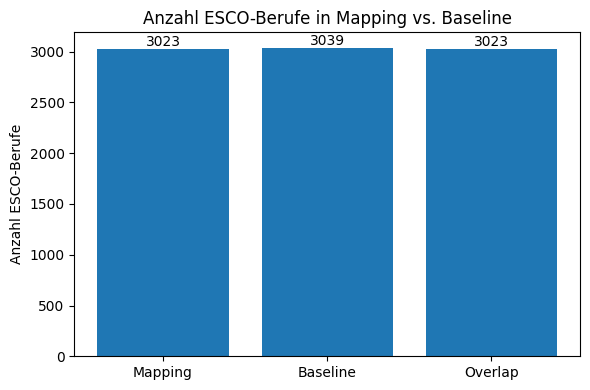

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ["Mapping", "Baseline", "Overlap"]
values = [n_mapping, n_baseline, n_overlap]

ax.bar(labels, values)
ax.set_title("Anzahl ESCO-Berufe in Mapping vs. Baseline")
ax.set_ylabel("Anzahl ESCO-Berufe")

for i, v in enumerate(values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

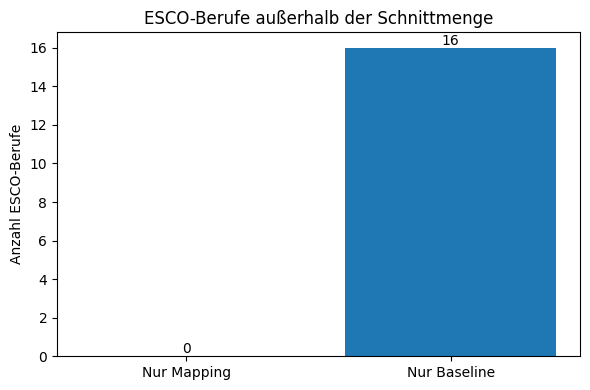

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ["Nur Mapping", "Nur Baseline"]
values = [only_mapping, only_baseline]

ax.bar(labels, values)
ax.set_title("ESCO-Berufe außerhalb der Schnittmenge")
ax.set_ylabel("Anzahl ESCO-Berufe")

for i, v in enumerate(values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 3. Linking KldB, ESCO Occupations, and Skills

Long join (each row: KldB, ESCO occupation, skill). The join significantly increases the number of rows, since a single ESCO occupation is referenced by multiple KldB codes and has multiple skills at the same time (many-to-many).

In [ ]:
kldb_skills_long = kldb_esco_mapping.merge(
    occupation_skills_baseline,
    on="occupation_uri",
    how="left",
    validate="many_to_many"
)

print("KldB + ESCO + Skills shape:", kldb_skills_long.shape)
kldb_skills_long.head(5)

KldB + ESCO + Skills shape: (809412, 24)


,kldb_5_code,kldb_title_de,kldb_title_en,isco08_4,isco_title_de,isco_title_en,unambiguous_flag,focus_and_alt_count,occupation_uri,esco_title_en,...,occupation_title_en,occupation_alt_labels_en,occupation_description_en,skill_uri,skill_title_en,skill_alt_labels_en,skill_description_en,reuse_level,skill_type,relation_type
0,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,fruit and vegetable picker,...,fruit and vegetable picker,['fruit picker\nfruit and vegetable harvester\...,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/0b34dd9f-bcb2...,apply health and safety when picking,['applying health and safety precautions when ...,Take the necessary health and safety precautio...,occupation-specific,skill/competence,essential
1,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,fruit and vegetable picker,...,fruit and vegetable picker,['fruit picker\nfruit and vegetable harvester\...,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/0e355580-bd4a...,work in outdoor conditions,['working in bad weather\nwork outdoors in adv...,Can cope with the different climate conditions...,cross-sector,skill/competence,essential
2,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,fruit and vegetable picker,...,fruit and vegetable picker,['fruit picker\nfruit and vegetable harvester\...,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/2e4e8114-e579...,harvest crop,['harvest crop\ncrop harvesting\ncrops harvest...,"Mow, pick or cut agricultural crop products ma...",sector-specific,skill/competence,essential
3,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,fruit and vegetable picker,...,fruit and vegetable picker,['fruit picker\nfruit and vegetable harvester\...,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/6d372e75-5ca1...,carry picking work aids,['fruit picking work aids carrying\nfruit pick...,"Carry work equipment, such as ladders, small c...",occupation-specific,skill/competence,essential
4,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,fruit and vegetable picker,...,fruit and vegetable picker,['fruit picker\nfruit and vegetable harvester\...,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/b9f621b2-fecb...,store crops,['preserving crops\npreserve crops\ncrops stor...,Store and preserve crops in accordance with st...,sector-specific,skill/competence,essential


An ESCO occupation can be referenced by multiple KldB codes, and since multiple skills exist for each ESCO occupation, a many-to-many relationship is created when they are joined.

In [ ]:
# Example: ESCO occupations with more than one KldB code
multi_kldb = (
    kldb_esco_mapping
    .groupby("occupation_uri")["kldb_5_code"]
    .nunique()
)

multi_kldb[multi_kldb > 1].head()

occupation_uri
http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34    6
http://data.europa.eu/esco/occupation/000e93a3-d956-4e45-aacb-f12c83fedf84    3
http://data.europa.eu/esco/occupation/0019b951-c699-4191-8208-9822882d150c    2
http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f    6
http://data.europa.eu/esco/occupation/0044c991-c26f-4261-a213-4bd1c0564a4c    3
Name: kldb_5_code, dtype: int64

## 4. Select relevant columns, Future Long Table

In [ ]:
kldb_skills_soll_long = kldb_skills_long[[
    # KldB
    "kldb_5_code","kldb_title_de","kldb_title_en",
    
    # Mapping Information (from the conversion key)
    "isco08_4","isco_title_de","isco_title_en","unambiguous_flag","focus_and_alt_count",
    
    # ESCO-Occupation
    "occupation_uri","occupation_code","isco_group","occupation_title_en","occupation_description_en",
    
    # Skill
    "skill_uri","skill_title_en","skill_description_en","reuse_level","skill_type",
    
    # Relation
    "relation_type",
]].copy()

print("kldb_skills_soll_long shape:", kldb_skills_soll_long.shape)
kldb_skills_soll_long.head(5)

kldb_skills_soll_long shape: (809412, 19)


,kldb_5_code,kldb_title_de,kldb_title_en,isco08_4,isco_title_de,isco_title_en,unambiguous_flag,focus_and_alt_count,occupation_uri,occupation_code,isco_group,occupation_title_en,occupation_description_en,skill_uri,skill_title_en,skill_description_en,reuse_level,skill_type,relation_type
0,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,9211.1,9211,fruit and vegetable picker,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/0b34dd9f-bcb2...,apply health and safety when picking,Take the necessary health and safety precautio...,occupation-specific,skill/competence,essential
1,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,9211.1,9211,fruit and vegetable picker,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/0e355580-bd4a...,work in outdoor conditions,Can cope with the different climate conditions...,cross-sector,skill/competence,essential
2,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,9211.1,9211,fruit and vegetable picker,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/2e4e8114-e579...,harvest crop,"Mow, pick or cut agricultural crop products ma...",sector-specific,skill/competence,essential
3,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,9211.1,9211,fruit and vegetable picker,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/6d372e75-5ca1...,carry picking work aids,"Carry work equipment, such as ladders, small c...",occupation-specific,skill/competence,essential
4,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,9211,Hilfsarbeiter im Ackerbau,Crop farm labourers,0,1,http://data.europa.eu/esco/occupation/373db468...,9211.1,9211,fruit and vegetable picker,Fruit and vegetable pickers select and harvest...,http://data.europa.eu/esco/skill/b9f621b2-fecb...,store crops,Store and preserve crops in accordance with st...,sector-specific,skill/competence,essential


## 5. Deduplication & Light Cleaning

In [ ]:
before = len(kldb_skills_soll_long)

kldb_skills_soll_long = (
    kldb_skills_soll_long
    .drop_duplicates(subset=["kldb_5_code","occupation_uri","skill_uri","relation_type"])
    .reset_index(drop=True)
)

after = len(kldb_skills_soll_long)
print(f"Zeilen vor/nach Deduplikation: {before} -> {after}")

Zeilen vor/nach Deduplikation: 809412 -> 809412


### 5.1 Add KldB job titles to the Future Long table

For each 5-digit KldB code, all specific job titles from the alphabetical list are aggregated and merged into the Future Long table as an additional column.

In [ ]:
# KldB code in the future long field as a clean string
kldb_skills_soll_long["kldb_5_code"] = kldb_skills_soll_long["kldb_5_code"].astype(str).str.zfill(5)

# Merge, add the aggregated job title column for each row
kldb_skills_soll_long = kldb_skills_soll_long.merge(
    job_titles_agg[["kldb_5_code", "kldb_job_titles_de"]],
    on="kldb_5_code",
    how="left"
)

print("kldb_skills_soll_long shape (with job titles):", kldb_skills_soll_long.shape)
display(
    kldb_skills_soll_long[["kldb_5_code", "kldb_title_de", "occupation_title_en", "skill_title_en", "kldb_job_titles_de"]]
    .head(10)
)

kldb_skills_soll_long shape (with job titles): (809412, 20)


,kldb_5_code,kldb_title_de,occupation_title_en,skill_title_en,kldb_job_titles_de
0,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,apply health and safety when picking,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
1,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,work in outdoor conditions,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
2,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,harvest crop,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
3,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,carry picking work aids,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
4,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,store crops,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
5,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,select fruits and vegetables,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
6,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,store products,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
7,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,maintain storage facilities,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
8,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,stack goods,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."
9,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,fruit and vegetable picker,load picked fruits and vegetables,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."


Result: an additional column containing all specific German job titles (one column, comma-separated)

## 6. Quality Checks for KldB Future Profiles

In [ ]:
# Number of KLDB codes, ESCO occupations, and skills
n_kldb_codes = kldb_skills_soll_long["kldb_5_code"].nunique()
n_occupations = kldb_skills_soll_long["occupation_uri"].nunique()
n_skills = kldb_skills_soll_long["skill_uri"].nunique()

print("Anzahl KldB-5-Steller im SOLL-Profil:", n_kldb_codes)
print("Anzahl unterschiedlicher ESCO-Berufe im SOLL-Profil:", n_occupations)
print("Anzahl unterschiedlicher Skills im SOLL-Profil:", n_skills)

Anzahl KldB-5-Steller im SOLL-Profil: 1300
Anzahl unterschiedlicher ESCO-Berufe im SOLL-Profil: 3023
Anzahl unterschiedlicher Skills im SOLL-Profil: 13471


In [ ]:
# ESCO occupations by KldB code
occ_per_kldb = (
    kldb_skills_soll_long
    .groupby("kldb_5_code")["occupation_uri"]
    .nunique()
)

print("Verteilung ESCO-Berufe pro KldB-Code:")
print(occ_per_kldb.describe())

# Skills per KldB code (distinct skill_uri)
skills_per_kldb = (
    kldb_skills_soll_long
    .groupby("kldb_5_code")["skill_uri"]
    .nunique()
)

print("\nVerteilung Skills pro KldB-Code:")
print(skills_per_kldb.describe())

Verteilung ESCO-Berufe pro KldB-Code:
count    1300.000000
mean       14.136923
std        13.651260
min         0.000000
25%         4.000000
50%        10.000000
75%        24.000000
max       106.000000
Name: occupation_uri, dtype: float64

Verteilung Skills pro KldB-Code:
count    1300.000000
mean      293.222308
std       242.799446
min         0.000000
25%       114.000000
50%       211.000000
75%       468.000000
max      1819.000000
Name: skill_uri, dtype: float64


Distribution metrics for ESCO-KldB:
- count = 1,300, number of 5-digit KldB codes with data
- mean = 14 ESCO occupations per KldB code; ESCO is more granular/broader; many ESCO occupations map to a single KldB code; 293 skills per KldB code due to the consolidation of many ESCO occupational skills
- std = high, significant variation
- min = 0; some KldB codes have no ESCO mapping
- 50% = 10 occupations/211 skills, as profiles are broad
- max = 106 ESCO occupations per KldB, broad and 1,819 skills, broad, many ESCO profiles
- Overall: KldB is coarser, ESCO is broad, many ESCO occupations per code due to mapping, skill sets grow through consolidation

In [ ]:
# Sample profile for a KldB code
example_kldb = kldb_skills_soll_long["kldb_5_code"].iloc[0]
print("Beispiel-KldB-Code:", example_kldb)

display(
    kldb_skills_soll_long
    .loc[kldb_skills_soll_long["kldb_5_code"] == example_kldb,
         ["kldb_5_code","kldb_title_de","kldb_job_titles_de","occupation_title_en","skill_title_en","relation_type","skill_type","reuse_level"]]
    .head(20)
)

Beispiel-KldB-Code: 11101


,kldb_5_code,kldb_title_de,kldb_job_titles_de,occupation_title_en,skill_title_en,relation_type,skill_type,reuse_level
0,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,apply health and safety when picking,essential,skill/competence,occupation-specific
1,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,work in outdoor conditions,essential,skill/competence,cross-sector
2,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,harvest crop,essential,skill/competence,sector-specific
3,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,carry picking work aids,essential,skill/competence,occupation-specific
4,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,store crops,essential,skill/competence,sector-specific
5,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,select fruits and vegetables,essential,skill/competence,sector-specific
6,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,store products,essential,skill/competence,sector-specific
7,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,maintain storage facilities,optional,skill/competence,cross-sector
8,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,stack goods,optional,skill/competence,cross-sector
9,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf...",fruit and vegetable picker,load picked fruits and vegetables,optional,skill/competence,sector-specific


## 7. Aggregated Version: Skill List by KldB Code

In [ ]:
kldb_skills_soll_agg = (
    kldb_skills_soll_long
    .groupby(
        ["kldb_5_code", "kldb_title_de", "kldb_title_en"],
        dropna=False
    )
    .apply(lambda df: df[[
        "skill_uri","skill_title_en","relation_type","skill_type","reuse_level"
    ]].to_dict("records"))
    .reset_index(name="skills")
)

print("Aggregierte Tabelle shape:", kldb_skills_soll_agg.shape)
kldb_skills_soll_agg.head(5)

Aggregierte Tabelle shape: (1300, 4)


C:\Users\floim\AppData\Local\Temp\ipykernel_28296\999609031.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df[[


,kldb_5_code,kldb_title_de,kldb_title_en,skills
0,01104,Offiziere,Commissioned officers,[{'skill_uri': 'http://data.europa.eu/esco/ski...
1,01203,Unteroffiziere mit Portepee,Senior non-commissioned officers and higher,[{'skill_uri': 'http://data.europa.eu/esco/ski...
2,01302,Unteroffiziere ohne Portepee,Junior non-commissioned officers,[{'skill_uri': 'http://data.europa.eu/esco/ski...
3,01402,Angehörige der regulären Streitkräfte in sonst...,Armed forces personnel in other ranks,[{'skill_uri': 'http://data.europa.eu/esco/ski...
4,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,[{'skill_uri': 'http://data.europa.eu/esco/ski...


Include the “Job Title” column in kldb_skills_soll_agg as well:

In [ ]:
# Normalize the KldB code as a string
kldb_skills_soll_agg["kldb_5_code"] = kldb_skills_soll_agg["kldb_5_code"].astype(str).str.zfill(5)

# Add a "Job Title" column
kldb_skills_soll_agg = kldb_skills_soll_agg.merge(
    job_titles_agg[["kldb_5_code", "kldb_job_titles_de"]],
    on="kldb_5_code",
    how="left"
)

print("Aggregierte Tabelle shape (with job titles):", kldb_skills_soll_agg.shape)
display(kldb_skills_soll_agg.head(5))

Aggregierte Tabelle shape (with job titles): (1300, 5)


,kldb_5_code,kldb_title_de,kldb_title_en,skills,kldb_job_titles_de
0,01104,Offiziere,Commissioned officers,[{'skill_uri': 'http://data.europa.eu/esco/ski...,"Offizier - Geoinformationsdienst, Offizier - M..."
1,01203,Unteroffiziere mit Portepee,Senior non-commissioned officers and higher,[{'skill_uri': 'http://data.europa.eu/esco/ski...,"Feldwebel - Allgemeiner Fachdienst, Feldwebel ..."
2,01302,Unteroffiziere ohne Portepee,Junior non-commissioned officers,[{'skill_uri': 'http://data.europa.eu/esco/ski...,"Fachunteroffizier - Allgemeiner Fachdienst, Fa..."
3,01402,Angehörige der regulären Streitkräfte in sonst...,Armed forces personnel in other ranks,[{'skill_uri': 'http://data.europa.eu/esco/ski...,Freiwil. Wehrdienstleistende/r - Laufbahngrupp...
4,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...,[{'skill_uri': 'http://data.europa.eu/esco/ski...,"Ackerarbeiter/in, Ackergehilf(e/in), Erntehelf..."


## 8. Saving to data/processed/

In [ ]:
# Long-form
long_out_path = DATA_PROCESSED / "kldb_skills_soll_long.parquet"
kldb_skills_soll_long.to_parquet(long_out_path, index=False)
print("Long-Format gespeichert in:", long_out_path)

# Aggregated version
agg_out_path = DATA_PROCESSED / "kldb_skills_soll_agg.parquet"
kldb_skills_soll_agg.to_parquet(agg_out_path, index=False)
print("Aggregierte Version gespeichert in:", agg_out_path)

Long-Format gespeichert in: C:\Users\floim\Studium\Masterthesis\masterthesis-profilerweiterung\data\processed\kldb_skills_soll_long.parquet
Aggregierte Version gespeichert in: C:\Users\floim\Studium\Masterthesis\masterthesis-profilerweiterung\data\processed\kldb_skills_soll_agg.parquet


In [ ]:
# also as a CSV file
csv_out_path = DATA_PROCESSED / "kldb_skills_soll_long.csv"
kldb_skills_soll_long.to_csv(csv_out_path, index=False)
print("CSV-Version gespeichert in:", csv_out_path)

CSV-Version gespeichert in: C:\Users\floim\Studium\Masterthesis\masterthesis-profilerweiterung\data\processed\kldb_skills_soll_long.csv


Save job titles separately:

In [ ]:
job_titles_long_out = DATA_PROCESSED / "kldb_job_titles_long.parquet"
job_titles_agg_out  = DATA_PROCESSED / "kldb_job_titles_agg.parquet"

job_titles.to_parquet(job_titles_long_out, index=False)
job_titles_agg.to_parquet(job_titles_agg_out, index=False)

print("Saved job_titles_long:", job_titles_long_out)
print("Saved job_titles_agg:", job_titles_agg_out)

Saved job_titles_long: C:\Users\floim\Studium\Masterthesis\masterthesis-profilerweiterung\data\processed\kldb_job_titles_long.parquet
Saved job_titles_agg: C:\Users\floim\Studium\Masterthesis\masterthesis-profilerweiterung\data\processed\kldb_job_titles_agg.parquet


# Conclusion Notebook 04

- KldB -> ESCO mapping (Notebook 02) linked to the ESCO skill baseline (Notebook 03)
- Result: Long table `kldb_skills_soll_long`, in which each row describes a 5-digit KldB code with an ESCO occupation and an assigned skill (including relation_type, skill_type, reuse_level)
- An aggregated table `kldb_skills_soll_agg` created via grouping, which contains a list of skills for each KldB code
- Both tables are stored in `data/processed/` and form the basis for further processing
- Additionally, the alphabetical directory of KldB occupation names was loaded, cleaned (CSV from data/raw/kldb/, including normalization of the 5-digit KldB codes, deduplication, aggregation per code), and merged, so that each skill entry now also includes the specific German job titles (aggregated and separated by commas).
- The aggregated job titles per KldB 5-digit code were merged into the Future Long table as an additional column named kldb_job_titles_de, so that each skill entry now also includes the specific German job titles associated with the KldB code.
- Additionally, the processed job title tables were saved separately for later independent reuse.